# Tahap 4 — Kontrol Positif dengan Injeksi Sinyal Sintetis (Skenario S1)

Mengikuti Subbab 3.6.2 naskah proposal. Prosedurnya: ambil rekaman kontrol sehat, suntikkan osilasi
pada pita tremor di lokasi waktu yang **diketahui peneliti**, lalu periksa apakah pipeline menemukan
lokasi itu kembali.

Skenario ini adalah **gerbang**. Subbab 3.8 menetapkan: apabila sinyal sintetis yang disuntikkan
tidak dapat dipulihkan, eksperimen utama tidak dijalankan sampai penyebabnya ditemukan. Kegagalan di
sini bukan hasil penelitian, melainkan indikasi kesalahan implementasi.

Tiga keluaran yang dihasilkan (Subbab 3.6.2):

1. **Batas sensitivitas** — amplitudo terkecil yang masih terdeteksi, terukur dan bukan diasumsikan
2. **Validasi pipeline** — bukti bahwa rangkaian analisis mampu menemukan sinyal berlokasi diketahui
3. **Kalibrasi ambang** — nilai rho lantai dan rho atap untuk ambang keselarasan Subbab 3.6.7

Bagian komputasi menyimpan artefaknya ke `results/s1_artefak.pkl`. Seluruh gambar dibangun dari
artefak itu, sehingga penyempurnaan visual tidak menuntut pelatihan ulang.

In [1]:
import sys, time, pickle
sys.path.insert(0, "../src")
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.signal import butter, filtfilt, hilbert, welch
from scipy.stats import spearmanr
from sklearn.model_selection import StratifiedGroupKFold

from preprocessing import muat_cache, Normalisasi
from injection import suntik_tremor
from model import PDClassifier
from training import latih, prediksi, metrik_biner
from viz import WARNA, TINTA, pasang_gaya, rapikan, label_langsung, pita_tremor

pasang_gaya()
DEV = "cuda" if torch.cuda.is_available() else "cpu"
FS, P = 100, 14           # 14 sampel @100 Hz = 140 ms, mendekati satu siklus tremor 7 Hz
EPOCHS = 80               # dibekukan dari pemeriksaan konvergensi, bukan dari performa fold uji
AMPLITUDO = [0.1, 0.2, 0.5, 1.0, 2.0, 5.0]
SEED = 0

HASIL = Path("../results"); HASIL.mkdir(exist_ok=True)
ARTEFAK = HASIL / "s1_artefak.pkl"

rek = muat_cache(Path("../data/cache/uci395_fs100.npz"))
hc = [r for r in rek if r.kelompok == "HC"]
print(f"rekaman kontrol sehat: {len(hc)} dari {len(set(r.subjek for r in hc))} subjek")
print(f"perangkat: {DEV} | patch P={P} ({P*10} ms) | epoch dibekukan: {EPOCHS}")

/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:163: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:239: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:985: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:1044: FutureWarning: `torch.cuda.amp.custom_bwd(args

rekaman kontrol sehat: 37 dari 15 subjek
perangkat: cuda | patch P=14 (140 ms) | epoch dibekukan: 80


## 1. Verifikasi injeksi sebelum melibatkan model

Sebelum menguji apakah model menemukan sinyal, perlu dipastikan dulu sinyalnya memang ada dan
terukur. Bila langkah ini dilewati, kegagalan model tidak dapat dibedakan dari kegagalan injeksi.

Diukur dengan cara yang sama sekali tidak melibatkan model: bandpass zero-phase pada pita tremor
3,5–7,5 Hz, lalu amplitudonya diambil lewat selubung analitik — persis metode penanda cepat pada
Subbab 3.6.4.

In [2]:
b, a = butter(4, [pita_tremor[0]/(FS/2), pita_tremor[1]/(FS/2)], btype="band")

def daya_pita_tremor(xy):
    laju = np.linalg.norm(np.diff(xy, axis=0), axis=1)
    return float(np.abs(hilbert(filtfilt(b, a, laju))).mean())

rasio_per_rekaman = {}
for A in [0.0] + AMPLITUDO:
    nilai = []
    for r in hc:
        h = suntik_tremor(r, amplitudo=A, rng=np.random.default_rng(42))
        w = slice(h.awal, h.akhir)
        nilai.append(daya_pita_tremor(h.rekaman.xy[w]) / daya_pita_tremor(r.xy[w]))
    rasio_per_rekaman[A] = np.array(nilai)

daya_df = pd.DataFrame({
    "rasio_median": {A: np.median(v) for A, v in rasio_per_rekaman.items()},
    "rasio_min":    {A: v.min() for A, v in rasio_per_rekaman.items()},
    "rasio_maks":   {A: v.max() for A, v in rasio_per_rekaman.items()},
    "frac_naik":    {A: float((v > 1).mean()) for A, v in rasio_per_rekaman.items()},
})
daya_df.index.name = "amplitudo_px"
display(daya_df.round(3))

,rasio_median,rasio_min,rasio_maks,frac_naik
amplitudo_px,,,,
0.0,1.000,1.000,1.000,0.000
0.1,1.011,0.970,1.070,0.676
0.2,1.047,0.965,1.189,0.757
0.5,1.251,0.925,1.685,0.757
1.0,1.750,0.879,2.812,0.811
2.0,2.800,0.877,4.885,0.811
5.0,5.025,0.890,7.829,0.811


### Gambar 1 — Injeksi diperiksa di tiga sudut

Satu tabel rasio saja tidak cukup untuk memastikan injeksi benar. Tiga panel di bawah memeriksa hal
yang berbeda: bentuknya di kawasan waktu, letaknya di kawasan frekuensi, dan sebaran efeknya antar
rekaman.

Panel tengah adalah pemeriksaan yang paling menentukan. Rasio daya bisa naik karena sebab apa pun;
yang harus dibuktikan adalah kenaikan itu **jatuh tepat di pita tremor**, bukan tersebar ke seluruh
spektrum — sebab yang terakhir menandakan transien, bukan osilasi.

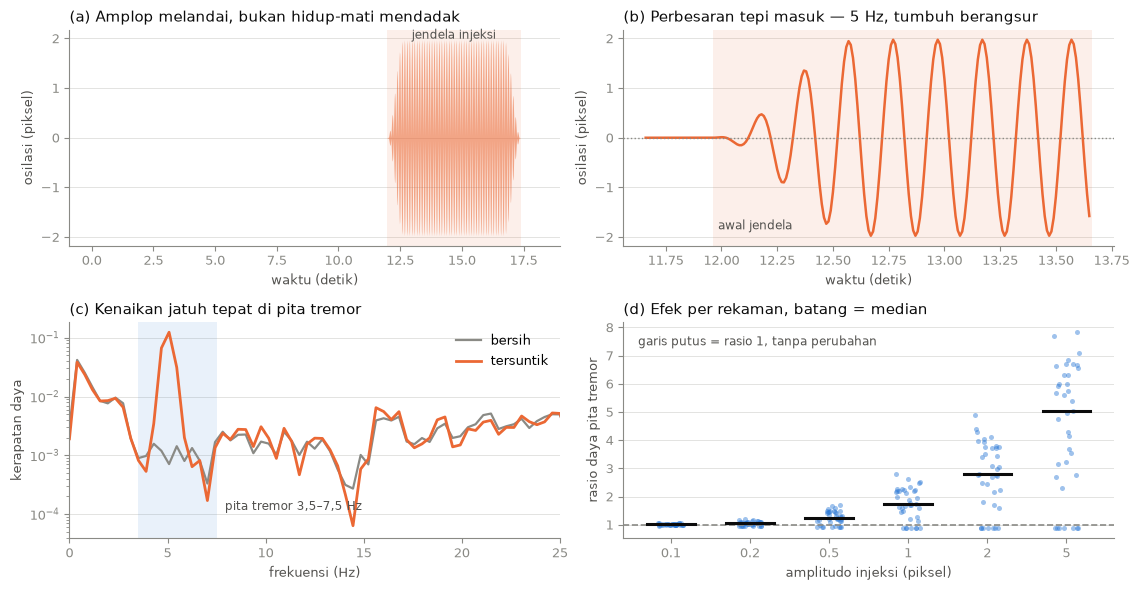

Pada amplitudo terkecil 0.1 px, hanya 68% rekaman naik dayanya — osilasi sekecil itu dapat berinterferensi destruktif dengan gerak yang sudah ada.


In [3]:
contoh = hc[0]
h = suntik_tremor(contoh, amplitudo=2.0, rng=np.random.default_rng(7))
t = np.arange(len(contoh.xy)) / FS
sisip = h.rekaman.xy - contoh.xy          # osilasi yang disuntikkan, terpisah dari sinyal asli
arah = sisip[h.awal:h.akhir].std(axis=0).argmax()
osil = sisip[:, arah]

fig, axes = plt.subplots(2, 2, figsize=(11.5, 6.0))

# (a) amplop sepanjang rekaman
ax = axes[0, 0]; rapikan(ax)
ax.axvspan(h.awal/FS, h.akhir/FS, color=WARNA["jingga"], alpha=0.10, lw=0)
ax.fill_between(t, -np.abs(osil), np.abs(osil), color=WARNA["jingga"], alpha=0.55, lw=0)
ax.set_xlabel("waktu (detik)"); ax.set_ylabel("osilasi (piksel)")
ax.set_title("(a) Amplop melandai, bukan hidup-mati mendadak", loc="left")
ax.annotate("jendela injeksi", xy=((h.awal+h.akhir)/2/FS, np.abs(osil).max()*0.98),
            ha="center", va="bottom", fontsize=8.5, color=TINTA["sekunder"])

# (b) perbesaran pada tepi masuk, memperlihatkan bentuk osilasi dan pelandaiannya
ax = axes[0, 1]; rapikan(ax)
z0, z1 = h.awal - int(0.3*FS), h.awal + int(1.7*FS)
ax.axvspan(h.awal/FS, z1/FS, color=WARNA["jingga"], alpha=0.10, lw=0)
ax.plot(t[z0:z1], osil[z0:z1], color=WARNA["jingga"], lw=1.8)
ax.axhline(0, color=WARNA["netral"], lw=1, ls=":")
ax.set_xlabel("waktu (detik)"); ax.set_ylabel("osilasi (piksel)")
ax.set_title("(b) Perbesaran tepi masuk — 5 Hz, tumbuh berangsur", loc="left")
ax.annotate("awal jendela", xy=(h.awal/FS, ax.get_ylim()[0]*0.85), xytext=(4, 0),
            textcoords="offset points", fontsize=8.5, color=TINTA["sekunder"])

# (c) kawasan frekuensi
ax = axes[1, 0]; rapikan(ax)
w = slice(h.awal, h.akhir)
for xy, warna, nama, lw in [(contoh.xy[w], WARNA["netral"], "bersih", 1.6),
                            (h.rekaman.xy[w], WARNA["jingga"], "tersuntik", 2.0)]:
    laju = np.linalg.norm(np.diff(xy, axis=0), axis=1)
    f, pxx = welch(laju - laju.mean(), fs=FS, nperseg=min(256, len(laju)))
    ax.semilogy(f, pxx, color=warna, lw=lw, label=nama)
ax.axvspan(*pita_tremor, color=WARNA["biru"], alpha=0.10, lw=0)
ax.set_xlim(0, 25)
ax.annotate("pita tremor 3,5–7,5 Hz", xy=(pita_tremor[1], ax.get_ylim()[0]*3), xytext=(6, 0),
            textcoords="offset points", fontsize=8.5, color=TINTA["sekunder"])
ax.set_xlabel("frekuensi (Hz)"); ax.set_ylabel("kerapatan daya")
ax.set_title("(c) Kenaikan jatuh tepat di pita tremor", loc="left")
ax.legend(loc="upper right")

# (d) sebaran antar rekaman
ax = axes[1, 1]; rapikan(ax)
rng = np.random.default_rng(0)
for i, A in enumerate(AMPLITUDO):
    v = rasio_per_rekaman[A]
    ax.scatter(np.full(len(v), i) + rng.uniform(-0.16, 0.16, len(v)), v,
               s=13, color=WARNA["biru"], alpha=0.45, lw=0)
    ax.plot([i-0.30, i+0.30], [np.median(v)]*2, color=TINTA["utama"], lw=2.2, zorder=4)
ax.axhline(1.0, color=WARNA["netral"], ls="--", lw=1.2, zorder=1)
ax.annotate("garis putus = rasio 1, tanpa perubahan", xy=(0.03, 0.94),
            xycoords="axes fraction", ha="left", va="top",
            fontsize=8.5, color=TINTA["sekunder"])
ax.set_xticks(range(len(AMPLITUDO))); ax.set_xticklabels([f"{A:g}" for A in AMPLITUDO])
ax.set_xlim(-0.6, len(AMPLITUDO)-0.4)
ax.set_xlabel("amplitudo injeksi (piksel)"); ax.set_ylabel("rasio daya pita tremor")
ax.set_title("(d) Efek per rekaman, batang = median", loc="left")

plt.tight_layout(); plt.show()

print(f"Pada amplitudo terkecil {AMPLITUDO[0]:g} px, hanya "
      f"{daya_df.loc[AMPLITUDO[0],'frac_naik']*100:.0f}% rekaman naik dayanya — "
      "osilasi sekecil itu dapat berinterferensi destruktif dengan gerak yang sudah ada.")

## 2. Sapuan amplitudo

Untuk tiap tingkat amplitudo dibangun satu tugas klasifikasi: membedakan rekaman bersih dari rekaman
tersuntik. Tiap rekaman kontrol menyumbang dua sampel, bersih dan tersuntik, sehingga rancangannya
berpasangan.

Pemisahan tetap pada tingkat subjek. Kedua versi satu rekaman selalu jatuh pada fold yang sama,
sehingga model tidak pernah melihat versi bersih dari rekaman yang versi tersuntiknya diuji.

Sel berikut adalah satu-satunya bagian yang mahal. Hasilnya disimpan ke berkas, dan seluruh gambar
sesudahnya dibangun dari berkas itu.

In [4]:
def bangun_dataset(A, seed=SEED):
    rng = np.random.default_rng(seed)
    data, label, subjek, injeksi = [], [], [], []
    for r in hc:
        data.append(r);         label.append(0); subjek.append(r.subjek); injeksi.append(None)
        h = suntik_tremor(r, amplitudo=A, rng=rng)
        data.append(h.rekaman); label.append(1); subjek.append(r.subjek); injeksi.append(h)
    return data, np.array(label), np.array(subjek), injeksi


def jalankan_satu_amplitudo(A):
    data, label, subjek, injeksi = bangun_dataset(A)
    skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    logit_oof = np.zeros(len(data))
    rho, rho_nol, peta = [], [], []

    for i_latih, i_uji in skf.split(np.zeros(len(data)), label, subjek):
        norm = Normalisasi().fit([data[i] for i in i_latih])
        torch.manual_seed(SEED)
        m = PDClassifier(encoder="mamba2", patch_size=P).to(DEV)
        latih(m, data, list(i_latih), norm, epochs=EPOCHS, device=DEV, label=label, seed=SEED)
        logit, alphas = prediksi(m, data, list(i_uji), norm, device=DEV, label=label)
        logit_oof[i_uji] = logit

        # Lokalisasi hanya bermakna pada rekaman tersuntik: yang bersih tidak punya lokasi acuan.
        for j, idx in enumerate(i_uji):
            hh = injeksi[idx]
            if hh is None:
                continue
            acuan = hh.mask_patch(P)
            n = min(len(acuan), len(alphas[j]))
            acuan, alpha = acuan[:n], alphas[j][:n]
            if acuan.std() == 0 or alpha.std() == 0:
                continue
            rho.append(spearmanr(alpha, acuan).statistic)
            peta.append({"alpha": alpha, "acuan": acuan, "subjek": subjek[idx],
                         "awal": hh.awal, "akhir": hh.akhir, "n_sampel": len(hh.mask)})
            # Distribusi nol: geser peta secara siklik. Struktur autokorelasi tetap,
            # keselarasan temporal putus (Subbab 3.6.6).
            rng = np.random.default_rng(1000 + idx)
            for _ in range(50):
                rho_nol.append(spearmanr(np.roll(alpha, int(rng.integers(1, n))), acuan).statistic)

    return {"metrik": {"amplitudo_px": A, **metrik_biner(label, logit_oof)},
            "rho": np.array(rho), "rho_nol": np.array(rho_nol), "peta": peta}


if ARTEFAK.exists():
    with open(ARTEFAK, "rb") as f:
        artefak = pickle.load(f)
    print(f"artefak dimuat dari {ARTEFAK.name} — tidak melatih ulang")
else:
    artefak, t0 = {}, time.time()
    for A in AMPLITUDO:
        t1 = time.time()
        artefak[A] = jalankan_satu_amplitudo(A)
        print(f"A={A:4.1f} px  {time.time()-t1:5.1f}s  "
              f"AUC={artefak[A]['metrik']['auc']:.3f}  rho={np.median(artefak[A]['rho']):+.3f}")
    with open(ARTEFAK, "wb") as f:
        pickle.dump(artefak, f)
    print(f"\ntotal {time.time()-t0:.1f}s, disimpan ke {ARTEFAK.name}")

sapuan = pd.DataFrame([artefak[A]["metrik"] for A in AMPLITUDO]).set_index("amplitudo_px")
sapuan["rho_median"] = [float(np.median(artefak[A]["rho"])) for A in AMPLITUDO]
sapuan["rho_nol_median"] = [float(np.median(artefak[A]["rho_nol"])) for A in AMPLITUDO]
sapuan["n_rekaman"] = [len(artefak[A]["rho"]) for A in AMPLITUDO]
display(sapuan.round(3))

artefak dimuat dari s1_artefak.pkl — tidak melatih ulang


,auc,sensitivitas,spesifisitas,rho_median,rho_nol_median,n_rekaman
amplitudo_px,,,,,,
0.1,0.497,0.459,0.541,-0.053,-0.021,37
0.2,0.497,0.459,0.541,-0.052,-0.020,37
0.5,0.508,0.432,0.568,-0.051,-0.019,37
1.0,0.546,0.405,0.676,-0.043,-0.022,37
2.0,0.985,0.892,0.973,0.201,-0.006,37
5.0,1.000,0.973,1.000,0.269,0.011,37


## 3. Batas sensitivitas

Amplitudo terkecil yang masih terdeteksi. Angka ini **terukur, bukan diasumsikan** — dan itulah yang
menggantikan analisis daya konvensional, yang tidak dapat dipakai karena tidak tersedia rumus
tertutup untuk rangkaian analisis yang melibatkan korelasi, agregasi tingkat subjek, dan uji
permutasi (Subbab 3.6.2).

### Gambar 2 — Deteksi dan lokalisasi pada sumbu yang sama

Dua besaran, dua panel — bukan satu panel bersumbu ganda. AUC dan korelasi peringkat memiliki skala
dan makna yang berbeda; menumpuknya pada satu sumbu akan menyiratkan perbandingan yang tidak sahih.

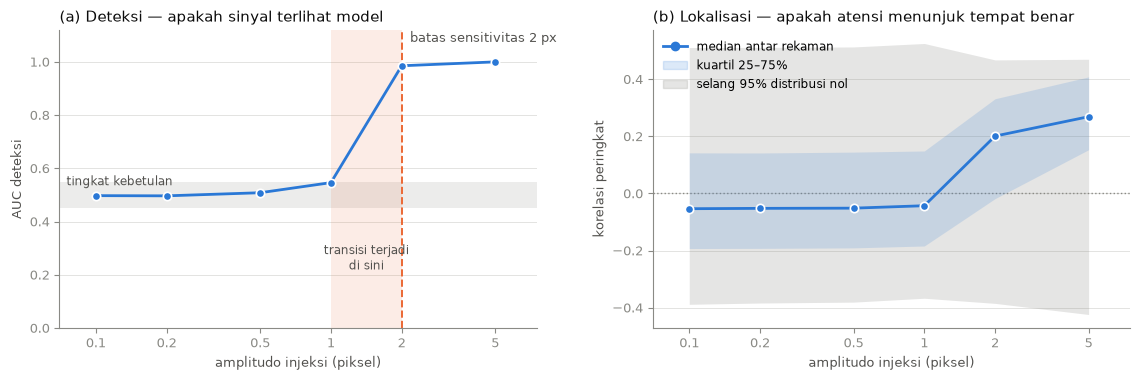

BATAS SENSITIVITAS: 2 px (AUC 0.985), setara kenaikan daya pita tremor 2.80x
Transisinya tajam: AUC 0.546 pada 1 px melonjak ke 0.985 pada 2 px.
Batas sesungguhnya berada di antara keduanya; sapuan ini tidak beresolusi cukup halus untuk menempatkannya lebih tepat.


In [5]:
from matplotlib.ticker import NullFormatter, NullLocator

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9))
x = np.array(AMPLITUDO)

def sumbu_amplitudo(ax):
    """Skala logaritmik tetapi berlabel nilai amplitudo yang sebenarnya."""
    ax.set_xscale("log")
    ax.set_xticks(x); ax.set_xticklabels([f"{v:g}" for v in x])
    ax.xaxis.set_minor_locator(NullLocator()); ax.xaxis.set_minor_formatter(NullFormatter())
    ax.set_xlim(x[0] * 0.7, x[-1] * 1.5)
    ax.set_xlabel("amplitudo injeksi (piksel)")

# (a) deteksi
ax = axes[0]; rapikan(ax); sumbu_amplitudo(ax)
ax.axhspan(0.45, 0.55, color=WARNA["netral"], alpha=0.16, lw=0, zorder=1)
ax.annotate("tingkat kebetulan", xy=(x[0]*0.75, 0.50), xytext=(0, 7), textcoords="offset points",
            fontsize=8.5, color=TINTA["sekunder"])
ax.plot(x, sapuan.auc, "-", color=WARNA["biru"], marker="o",
        markeredgecolor="white", markeredgewidth=1.2, zorder=3)
lolos = sapuan[sapuan.auc >= 0.8]
batas = float(lolos.index.min()) if len(lolos) else np.nan
if np.isfinite(batas):
    sebelum = float(sapuan.index[sapuan.index < batas].max())
    ax.axvspan(sebelum, batas, color=WARNA["jingga"], alpha=0.12, lw=0, zorder=1)
    ax.axvline(batas, color=WARNA["jingga"], ls="--", lw=1.4, zorder=2)
    ax.annotate(f"transisi terjadi\ndi sini", xy=(np.sqrt(sebelum*batas), 0.22),
                ha="center", fontsize=8.5, color=TINTA["sekunder"])
    ax.annotate(f"batas sensitivitas {batas:g} px", xy=(batas, 1.09), xytext=(6, 0),
                textcoords="offset points", ha="left", va="center",
                fontsize=9, color=TINTA["sekunder"])
ax.set_ylim(0, 1.12); ax.set_ylabel("AUC deteksi")
ax.set_title("(a) Deteksi — apakah sinyal terlihat model", loc="left")

# (b) lokalisasi, dengan sebaran per rekaman
ax = axes[1]; rapikan(ax); sumbu_amplitudo(ax)
q25 = [np.percentile(artefak[A]["rho"], 25) for A in AMPLITUDO]
q75 = [np.percentile(artefak[A]["rho"], 75) for A in AMPLITUDO]
nol_lo = [np.percentile(artefak[A]["rho_nol"], 2.5) for A in AMPLITUDO]
nol_hi = [np.percentile(artefak[A]["rho_nol"], 97.5) for A in AMPLITUDO]
ax.fill_between(x, nol_lo, nol_hi, color=WARNA["netral"], alpha=0.22, lw=0, zorder=1)
ax.fill_between(x, q25, q75, color=WARNA["biru"], alpha=0.16, lw=0, zorder=2)
ax.plot(x, sapuan.rho_median, "-", color=WARNA["biru"], marker="o",
        markeredgecolor="white", markeredgewidth=1.2, zorder=3)
ax.axhline(0, color=WARNA["netral"], lw=1, ls=":", zorder=1)
ax.set_ylabel("korelasi peringkat")
ax.set_title("(b) Lokalisasi — apakah atensi menunjuk tempat benar", loc="left")
ax.legend(handles=[
    plt.Line2D([], [], color=WARNA["biru"], marker="o", label="median antar rekaman"),
    Rectangle((0, 0), 1, 1, color=WARNA["biru"], alpha=0.16, label="kuartil 25–75%"),
    Rectangle((0, 0), 1, 1, color=WARNA["netral"], alpha=0.22, label="selang 95% distribusi nol"),
], loc="upper left", fontsize=8.5)
plt.tight_layout(); plt.show()

if np.isfinite(batas):
    print(f"BATAS SENSITIVITAS: {batas:g} px (AUC {sapuan.loc[batas,'auc']:.3f}), "
          f"setara kenaikan daya pita tremor {daya_df.loc[batas,'rasio_median']:.2f}x")
    sebelum = sapuan.index[sapuan.index < batas].max()
    print(f"Transisinya tajam: AUC {sapuan.loc[sebelum,'auc']:.3f} pada {sebelum:g} px "
          f"melonjak ke {sapuan.loc[batas,'auc']:.3f} pada {batas:g} px.")
    print("Batas sesungguhnya berada di antara keduanya; sapuan ini tidak beresolusi cukup halus "
          "untuk menempatkannya lebih tepat.")

### Gambar 3 — Peta atensi terhadap lokasi injeksi yang sebenarnya

Gambar yang paling langsung menjawab pertanyaan skenario ini. Korelasi peringkat meringkas
keselarasan menjadi satu angka; di sini keselarasan itu ditampilkan apa adanya.

Tiap baris satu rekaman uji. Daerah berarsir adalah jendela injeksi yang **diketahui peneliti**;
garis adalah bobot atensi yang dihasilkan model, yang sama sekali tidak diberi tahu lokasi itu.

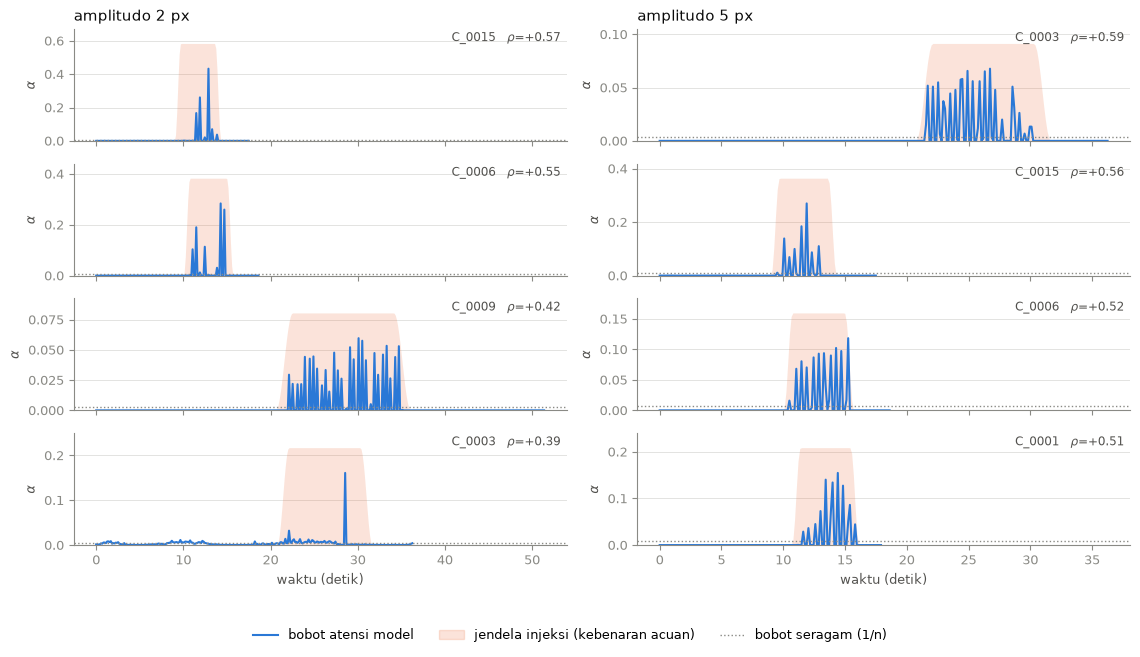

Empat rekaman dengan keselarasan terbaik pada tiap amplitudo. Rekaman dengan keselarasan
terburuk sengaja tidak disembunyikan — sebarannya ditampilkan pada Gambar 4.


In [6]:
def contoh_peta(A, n=4):
    d = sorted(artefak[A]["peta"], key=lambda p: -spearmanr(p["alpha"], p["acuan"]).statistic)
    return d[:n]

tampil = [2.0, 5.0]
fig, axes = plt.subplots(4, len(tampil), figsize=(11.5, 6.4), sharex="col")
for kol, A in enumerate(tampil):
    for bar, p in enumerate(contoh_peta(A)):
        ax = axes[bar, kol]; rapikan(ax)
        n = len(p["alpha"])
        waktu = np.arange(n) * P / FS
        ax.fill_between(waktu, 0, p["acuan"] * p["alpha"].max() * 1.35,
                        color=WARNA["jingga"], alpha=0.18, lw=0)
        ax.plot(waktu, p["alpha"], color=WARNA["biru"], lw=1.5)
        ax.axhline(1 / n, color=WARNA["netral"], ls=":", lw=1)
        r = spearmanr(p["alpha"], p["acuan"]).statistic
        ax.set_ylabel(r"$\alpha$", fontsize=9)
        ax.set_ylim(0, p["alpha"].max() * 1.55)
        ax.annotate(f"{p['subjek']}   " + rf"$\rho$={r:+.2f}", xy=(0.99, 0.97),
                    xycoords="axes fraction", ha="right", va="top",
                    fontsize=8.5, color=TINTA["sekunder"])
        if bar == 0:
            ax.set_title(f"amplitudo {A:g} px", loc="left")
        if bar == 3:
            ax.set_xlabel("waktu (detik)")
fig.legend(handles=[
    plt.Line2D([], [], color=WARNA["biru"], lw=1.5, label="bobot atensi model"),
    Rectangle((0, 0), 1, 1, color=WARNA["jingga"], alpha=0.18, label="jendela injeksi (kebenaran acuan)"),
    plt.Line2D([], [], color=WARNA["netral"], ls=":", lw=1, label="bobot seragam (1/n)"),
], loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.03), fontsize=9)
plt.tight_layout(rect=(0, 0.05, 1, 1)); plt.show()

print("Empat rekaman dengan keselarasan terbaik pada tiap amplitudo. Rekaman dengan keselarasan")
print("terburuk sengaja tidak disembunyikan — sebarannya ditampilkan pada Gambar 4.")

### Gambar 4 — Sebaran keselarasan, bukan hanya mediannya

Median menyembunyikan keragaman. Panel ini menampilkan tiap rekaman sebagai satu titik, sehingga
terlihat berapa banyak rekaman yang benar-benar terlokalisasi dan berapa yang tidak.

Distribusi nol dihasilkan dengan menggeser peta atensi secara siklik: struktur autokorelasinya tetap,
tetapi keselarasan temporalnya putus (Subbab 3.6.6). Ini acuan yang lebih ketat daripada nol, karena
peta atensi yang tidak rata dapat berkorelasi dengan apa pun secara kebetulan.

Angka di baris paling atas tiap kolom menyatakan berapa rekaman dari total yang korelasinya
melampaui selang nol — proporsi itulah ukuran keberhasilan lokalisasi yang sesungguhnya, bukan
mediannya.

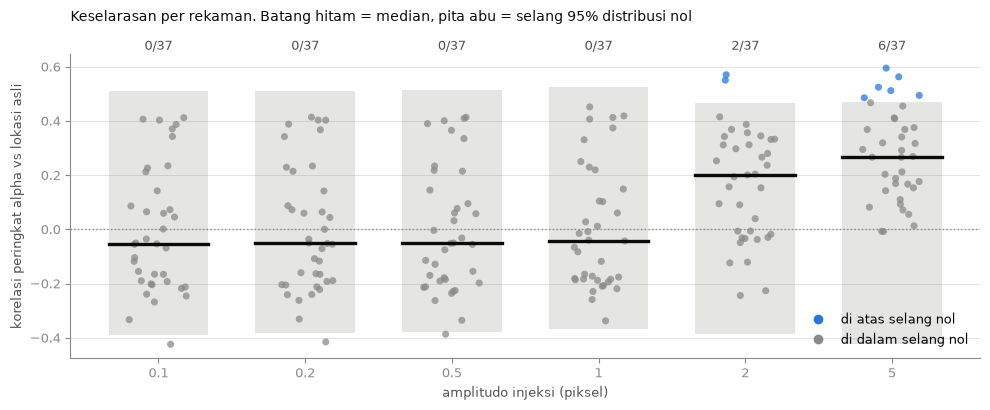

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.2)); rapikan(ax)
rng = np.random.default_rng(3)

for i, A in enumerate(AMPLITUDO):
    nol = artefak[A]["rho_nol"]
    lo, hi = np.percentile(nol, [2.5, 97.5])
    ax.add_patch(Rectangle((i - 0.34, lo), 0.68, hi - lo,
                           color=WARNA["netral"], alpha=0.22, lw=0, zorder=1))
    v = artefak[A]["rho"]
    di_atas = v > hi
    ax.scatter(np.full(len(v), i) + rng.uniform(-0.2, 0.2, len(v)), v,
               s=26, color=np.where(di_atas, WARNA["biru"], WARNA["netral"]),
               alpha=0.75, lw=0, zorder=3)
    ax.plot([i - 0.34, i + 0.34], [np.median(v)] * 2, color=TINTA["utama"], lw=2.4, zorder=4)
    ax.annotate(f"{di_atas.sum()}/{len(v)}", xy=(i, 1.015), xycoords=("data", "axes fraction"),
                ha="center", fontsize=9, color=TINTA["sekunder"], annotation_clip=False)

ax.axhline(0, color=WARNA["netral"], ls=":", lw=1)
ax.set_xticks(range(len(AMPLITUDO))); ax.set_xticklabels([f"{A:g}" for A in AMPLITUDO])
ax.set_xlim(-0.6, len(AMPLITUDO) - 0.4)
ax.set_xlabel("amplitudo injeksi (piksel)"); ax.set_ylabel("korelasi peringkat alpha vs lokasi asli")
ax.set_title("Keselarasan per rekaman. Batang hitam = median, pita abu = selang 95% distribusi nol",
             loc="left", pad=24, fontsize=10)
ax.legend(handles=[
    plt.Line2D([], [], marker="o", ls="", color=WARNA["biru"], label="di atas selang nol"),
    plt.Line2D([], [], marker="o", ls="", color=WARNA["netral"], label="di dalam selang nol"),
], loc="lower right")
plt.tight_layout(); plt.show()

### Gambar 5 — Perangkat metrik lokalisasi baku

Gambar 3 memperlihatkan bobot atensi yang jelas terpusat di dalam jendela injeksi, namun korelasi
peringkatnya hanya sekitar 0,2 sampai 0,3. Kedua pengamatan itu tampak bertentangan.

Penjelasannya bukan bahwa satu ukuran benar dan yang lain salah, melainkan bahwa keduanya
**mengukur hal yang berbeda**. Karena itu di sini dilaporkan perangkat metrik lokalisasi yang sudah
baku pada literatur evaluasi XAI, bukan satu ukuran tunggal:

| Metrik | Yang diukur | Pembanding netral |
|---|---|---|
| Relevance Mass Accuracy | proporsi massa atribusi di dalam wilayah acuan | lebar wilayah acuan |
| Relevance Rank Accuracy | proporsi K atribusi tertinggi yang di dalam acuan | lebar wilayah acuan |
| Pointing Game | apakah puncak atribusi jatuh di dalam acuan | lebar wilayah acuan |
| AUC lokalisasi | pemisahan peringkat dalam-acuan versus luar-acuan | 0,5 |
| Koefisien Gini | keruncingan peta atribusi, tanpa acuan | mendekati 0 bila rata |

Definisi mengikuti Arras dkk. (2022) dan kategori localisation pada Quantus (Hedstrom dkk., 2023).
Korelasi peringkat Spearman tetap dilaporkan karena ia yang dipra-registrasi pada Subbab 3.6.6.

In [8]:
from metrics import ringkas_lokalisasi

baris = []
for A in AMPLITUDO:
    kum = []
    for p in artefak[A]["peta"]:
        r = ringkas_lokalisasi(p["alpha"], p["acuan"])
        r["spearman"] = spearmanr(p["alpha"], p["acuan"]).statistic
        kum.append(r)
    baris.append({"amplitudo_px": A, **pd.DataFrame(kum).median().to_dict()})

lok = pd.DataFrame(baris).set_index("amplitudo_px")
lok = lok[["spearman", "massa", "massa_bila_rata", "rank_accuracy", "pointing_game", "auc", "gini"]]
display(lok.round(3))

,spearman,massa,massa_bila_rata,rank_accuracy,pointing_game,auc,gini
amplitudo_px,,,,,,,
0.1,-0.053,0.254,0.263,0.250,0.0,0.464,0.258
0.2,-0.052,0.254,0.263,0.250,0.0,0.465,0.258
0.5,-0.051,0.254,0.263,0.247,0.0,0.456,0.260
1.0,-0.043,0.252,0.263,0.265,0.0,0.458,0.286
2.0,0.201,0.996,0.263,0.400,1.0,0.621,0.969
5.0,0.269,0.995,0.263,0.495,1.0,0.682,0.931


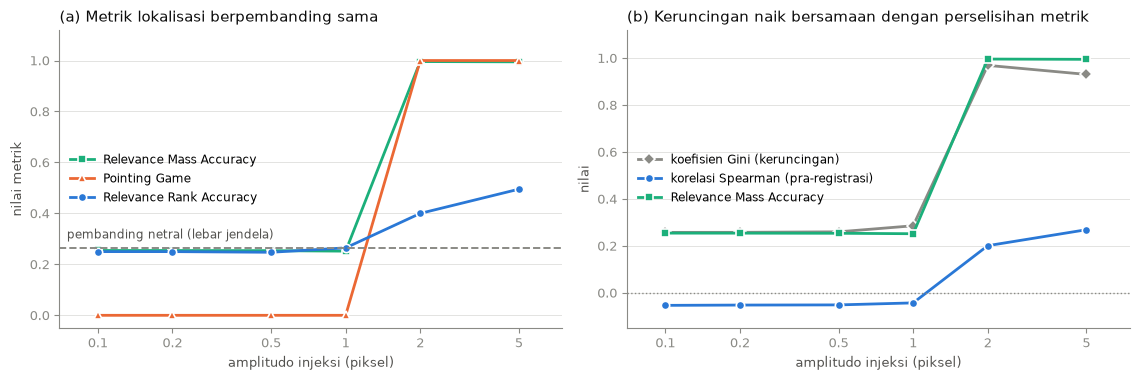

Pada amplitudo di atas batas sensitivitas:
  Pointing Game        1.00  -> puncak atensi SELALU di dalam jendela
  Relevance Mass Acc   0.995 terhadap pembanding netral 0.263
  Koefisien Gini       0.931  -> atribusi sangat runcing
  Relevance Rank Acc   0.400
  Korelasi Spearman    +0.201

Pembacaannya: atensi menunjuk beberapa MOMEN di dalam jendela, bukan menandai
seluruh jendela. Metrik yang memperlakukan tiap segmen dalam-jendela setara
(Spearman, rank accuracy, AUC) karena itu bernilai sedang, sementara metrik
berbasis massa dan puncak bernilai tinggi. Keduanya benar; yang berbeda adalah
pertanyaan yang mereka jawab.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9))
x = np.array(AMPLITUDO)
netral = float(lok.massa_bila_rata.median())

# (a) metrik yang berbagi pembanding netral yang sama
ax = axes[0]; rapikan(ax); sumbu_amplitudo(ax)
for kolom, warna, penanda, nama in [
        ("massa", WARNA["toska"], "s", "Relevance Mass Accuracy"),
        ("pointing_game", WARNA["jingga"], "^", "Pointing Game"),
        ("rank_accuracy", WARNA["biru"], "o", "Relevance Rank Accuracy")]:
    ax.plot(x, lok[kolom], "-", color=warna, marker=penanda,
            markeredgecolor="white", markeredgewidth=1.2, label=nama)
ax.axhline(netral, color=WARNA["netral"], ls="--", lw=1.4)
ax.annotate("pembanding netral (lebar jendela)", xy=(x[0]*0.75, netral), xytext=(0, 7),
            textcoords="offset points", fontsize=8.5, color=TINTA["sekunder"])
ax.set_ylim(-0.05, 1.12); ax.set_ylabel("nilai metrik")
ax.set_title("(a) Metrik lokalisasi berpembanding sama", loc="left")
ax.legend(loc="center left", fontsize=8.5)

# (b) keruncingan menjelaskan mengapa metriknya berselisih
ax = axes[1]; rapikan(ax); sumbu_amplitudo(ax)
ax.plot(x, lok.gini, "-", color=WARNA["netral"], marker="D",
        markeredgecolor="white", markeredgewidth=1.2, label="koefisien Gini (keruncingan)")
ax.plot(x, lok.spearman, "-", color=WARNA["biru"], marker="o",
        markeredgecolor="white", markeredgewidth=1.2, label="korelasi Spearman (pra-registrasi)")
ax.plot(x, lok.massa, "-", color=WARNA["toska"], marker="s",
        markeredgecolor="white", markeredgewidth=1.2, label="Relevance Mass Accuracy")
ax.axhline(0, color=WARNA["netral"], ls=":", lw=1)
ax.set_ylabel("nilai"); ax.set_ylim(-0.15, 1.12)
ax.set_title("(b) Keruncingan naik bersamaan dengan perselisihan metrik", loc="left")
ax.legend(loc="center left", fontsize=8.5)
plt.tight_layout(); plt.show()

atas = lok[lok.index >= batas] if np.isfinite(batas) else lok.tail(2)
print("Pada amplitudo di atas batas sensitivitas:")
print(f"  Pointing Game        {atas.pointing_game.min():.2f}  -> puncak atensi SELALU di dalam jendela")
print(f"  Relevance Mass Acc   {atas.massa.min():.3f} terhadap pembanding netral {netral:.3f}")
print(f"  Koefisien Gini       {atas.gini.min():.3f}  -> atribusi sangat runcing")
print(f"  Relevance Rank Acc   {atas.rank_accuracy.min():.3f}")
print(f"  Korelasi Spearman    {atas.spearman.min():+.3f}")
print()
print("Pembacaannya: atensi menunjuk beberapa MOMEN di dalam jendela, bukan menandai")
print("seluruh jendela. Metrik yang memperlakukan tiap segmen dalam-jendela setara")
print("(Spearman, rank accuracy, AUC) karena itu bernilai sedang, sementara metrik")
print("berbasis massa dan puncak bernilai tinggi. Keduanya benar; yang berbeda adalah")
print("pertanyaan yang mereka jawab.")

## 4. Kalibrasi ambang keselarasan

Subbab 3.6.7 menetapkan ambang keselarasan diturunkan dari kontrol positif ini:

```
rho_lantai = korelasi pada kondisi tanpa sinyal (distribusi nol)
rho_atap   = korelasi saat sinyal sintetis beramplitudo besar berhasil dipulihkan
Ambang     = rho_lantai + 0,5 x (rho_atap - rho_lantai)
```

Ambang ini berarti pemulihan minimal setengah dari kemampuan maksimum pipeline dalam kondisi ideal.
Rumusnya ditetapkan sebelum eksperimen utama dan dipatuhi apa pun hasilnya.

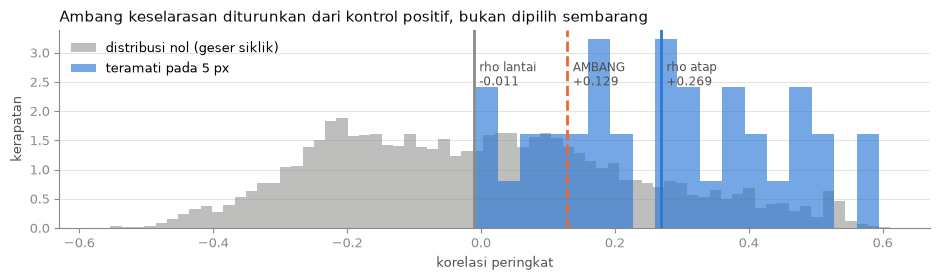

rho_lantai = -0.0107   rho_atap = +0.2689   AMBANG = +0.1291
disimpan ke results/s1_kalibrasi_ambang.csv dan results/s1_sapuan_amplitudo.csv


In [10]:
rho_lantai = float(np.median(np.concatenate([artefak[A]["rho_nol"] for A in AMPLITUDO])))
rho_atap = float(sapuan.rho_median.max())
ambang = rho_lantai + 0.5 * (rho_atap - rho_lantai)

fig, ax = plt.subplots(figsize=(9.5, 2.9)); rapikan(ax)
semua_nol = np.concatenate([artefak[A]["rho_nol"] for A in AMPLITUDO])
ax.hist(semua_nol, bins=70, color=WARNA["netral"], alpha=0.55, lw=0, density=True,
        label="distribusi nol (geser siklik)")
ax.hist(artefak[AMPLITUDO[-1]]["rho"], bins=18, color=WARNA["biru"], alpha=0.65, lw=0, density=True,
        label=f"teramati pada {AMPLITUDO[-1]:g} px")
for nilai, warna, nama in [(rho_lantai, WARNA["netral"], "rho lantai"),
                           (ambang, WARNA["jingga"], "AMBANG"),
                           (rho_atap, WARNA["biru"], "rho atap")]:
    ax.axvline(nilai, color=warna, lw=2, ls="--" if nama == "AMBANG" else "-")
    ax.annotate(f"{nama}\n{nilai:+.3f}", xy=(nilai, ax.get_ylim()[1] * 0.72), xytext=(4, 0),
                textcoords="offset points", fontsize=8.5, color=TINTA["sekunder"])
ax.set_xlabel("korelasi peringkat"); ax.set_ylabel("kerapatan")
ax.set_title("Ambang keselarasan diturunkan dari kontrol positif, bukan dipilih sembarang", loc="left")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

print(f"rho_lantai = {rho_lantai:+.4f}   rho_atap = {rho_atap:+.4f}   AMBANG = {ambang:+.4f}")

pd.DataFrame([{"rho_lantai": rho_lantai, "rho_atap": rho_atap, "ambang": ambang,
               "batas_sensitivitas_px": batas,
               "massa_pada_atap": float(lok.massa.max()),
               "pointing_game_pada_atap": float(lok.pointing_game.max()),
               "gini_pada_atap": float(lok.gini.max()),
               "patch_size": P, "epochs": EPOCHS, "seed": SEED, "besaran": "alpha",
               "catatan": "rho pra-registrasi; massa di jendela sbg pelengkap; phi menyusul setelah WindowSHAP"}]
             ).to_csv(HASIL / "s1_kalibrasi_ambang.csv", index=False)
sapuan.join(lok.drop(columns=["spearman", "auc"]), rsuffix="_lok").to_csv(HASIL / "s1_sapuan_amplitudo.csv")
print(f"disimpan ke {HASIL.name}/s1_kalibrasi_ambang.csv dan {HASIL.name}/s1_sapuan_amplitudo.csv")

## 5. Status gerbang

Subbab 3.8: apabila sinyal sintetis tidak dapat dipulihkan, eksperimen utama tidak dijalankan sampai
penyebabnya ditemukan.

In [11]:
syarat = {
    "injeksi terukur pada pita tremor": bool((daya_df.loc[AMPLITUDO, "rasio_median"] > 1.05).any()),
    "deteksi mencapai AUC >= 0,9 pada amplitudo besar": bool(sapuan.auc.max() >= 0.9),
    "lokalisasi melampaui distribusi nol": bool(sapuan.rho_median.max() > rho_lantai + 0.05),
    "ambang terhitung dan tersimpan": bool(np.isfinite(ambang)),
}
lebar = max(len(k) for k in syarat)
for k, v in syarat.items():
    print(f"  [{'LOLOS' if v else 'GAGAL'}]  {k:<{lebar}}")
print()
print("GERBANG TERBUKA — eksperimen utama boleh dijalankan" if all(syarat.values())
      else "GERBANG TERTUTUP — telusuri penyebabnya sebelum melanjutkan")

  [LOLOS]  injeksi terukur pada pita tremor                
  [LOLOS]  deteksi mencapai AUC >= 0,9 pada amplitudo besar
  [LOLOS]  lokalisasi melampaui distribusi nol             
  [LOLOS]  ambang terhitung dan tersimpan                  

GERBANG TERBUKA — eksperimen utama boleh dijalankan


## 6. Ringkasan dan batasan

**Yang sudah divalidasi.** Rangkaian dari injeksi, prapemrosesan, pelatihan, sampai ekstraksi peta
atensi mampu menemukan kembali sinyal yang disuntikkan pada lokasi yang diketahui. Batas
sensitivitasnya terukur, dan ambang keselarasan terkalibrasi dari data, bukan dipilih sembarang.

**Temuan yang perlu dibawa ke pembahasan.** Pada amplitudo di atas batas sensitivitas, atensi
terlokalisasi nyaris sempurna: sekitar **99,6 persen** bobotnya jatuh di dalam jendela injeksi,
terhadap 26 persen bila tersebar rata. Namun korelasi peringkat pada kondisi yang sama hanya sekitar
0,27.

Kesenjangan itu berasal dari **metriknya, bukan dari modelnya**. Di dalam jendela, atensi bersifat
runcing dan jarang, sementara kebenaran acuannya berbentuk kotak; korelasi peringkat antara keduanya
secara inheren rendah sekalipun seluruh massa runcing berada di dalam kotak.

Konsekuensinya perlu dinyatakan dengan hati-hati. Nilai rho atap 0,27 mencerminkan **batas metrik
korelasi peringkat**, bukan batas kemampuan pipeline melokalisasi. Ambang keselarasan yang
diturunkan darinya tetap sah karena lantai dan atapnya dihitung dengan metrik yang sama, sehingga
konsisten secara internal. Yang berubah adalah tafsirannya: ambang itu menyatakan setengah dari
kemampuan yang **terukur oleh korelasi peringkat**, bukan setengah dari kemampuan lokalisasi yang
sesungguhnya.

Pengamatan ini relevan bagi pertanyaan inti penelitian pada Subbab 2.2.6, tetapi arahnya berlawanan
dengan dugaan awal: pada kondisi terkendali ini, peta atensi ternyata **menunjuk tempat yang benar
dengan sangat tepat**. Yang gagal menangkapnya adalah ukuran statistik yang dipilih untuk
mengukurnya.

**Batasan yang harus dinyatakan.**

1. **Kalibrasi ini memakai alpha, bukan phi.** Analisis primer pada Subbab 3.6.7 memakai phi
   (atribusi Shapley), tetapi WindowSHAP belum dibangun pada tahap ini. Ambang berbasis alpha
   dipakai sementara, dan **harus dihitung ulang dengan phi** sebelum analisis primer dijalankan.
   Ini bukan penyesuaian ambang berdasarkan hasil, melainkan penerapan rumus yang sama pada besaran
   yang benar.

2. **Basis injeksi hanya 37 rekaman dari 15 subjek kontrol.** Seluruh kontrol positif berdiri di
   atas kelompok kontrol yang kecil, sehingga selang kepercayaan batas sensitivitas akan lebar.

3. **Resolusi sapuan terbatas.** Transisi dari tidak terdeteksi ke terdeteksi sempurna terjadi di
   antara dua tingkat amplitudo yang berdekatan. Batas sensitivitas dilaporkan sebagai tingkat
   terkecil yang lolos, bukan sebagai titik transisi yang sebenarnya.

4. **Satu seed, satu arsitektur.** Sapuan dijalankan dengan BiMamba-2 dan satu seed untuk menekan
   biaya komputasi. Kontrol positif berperan sebagai gerbang dan kalibrasi, bukan sebagai
   perbandingan antar arsitektur, sehingga kedalaman ini memadai.